In [ ]:
from mermaid import Mermaid
Mermaid("""
mindmap
  root((torch_dtype))
    integer
      int8
      int16
      int32
      int64
    floating
      float16
      float32
      float64
""")

PyTorch                C++
------------------------------------------------
torch.bool             bool

torch.int8             int8_t
torch.int16            int16_t
torch.int32            int
torch.int64            long long

torch.float16          half
torch.bfloat16         bfloat16
torch.float32          float
torch.float64          double

torch.complex64        complex<float>
torch.complex128       complex<double>

In [ ]:
import torch

dtype = torch.float
device = torch.device("cpu")

a = torch.randn(2,3, device=device, dtype=dtype)
b = torch.randn(2,3, device=device, dtype=dtype)

print("tensor a: ")
print(a)

print("tensor b: ")
print(b)

c = a * b
print("tensor c: ")
print(c)

print("sum of tensor a: ", a.sum().item())
print("max of tensor a: ", a.max().item())
print("min of tensor a: ", a.min().item())
print("mean of tensor a: ", a.mean().item())
print("std of tensor a: ", a.std().item())
print("prod of tensor a: ", a.prod().item())



tensor a: 
tensor([[ 0.3933,  0.1089,  0.4264],
        [-1.9539, -0.3507, -0.1318]])
tensor b: 
tensor([[ 0.6611,  2.2968,  2.4328],
        [ 0.1935,  1.0885, -1.2516]])
tensor c: 
tensor([[ 0.2600,  0.2502,  1.0374],
        [-0.3782, -0.3818,  0.1650]])
sum of tensor a:  -1.5077968835830688
max of tensor a:  0.426421195268631
min of tensor a:  -1.95392644405365
mean of tensor a:  -0.2512994706630707
std of tensor a:  0.8863067030906677
prod of tensor a:  -0.0016501080244779587
sum of tensor a:  -1.5077968835830688


1. 学习 PyTorch 其实就是学习
数据
 ↓
Tensor
 ↓
模型(nn.Module)
 ↓
Loss
 ↓
Backpropagation
 ↓
Optimizer
 ↓
训练完成
2. PyTorch 模块总览
torch
├── tensor
├── autograd
├── cuda
├── nn
├── optim
├── utils.data
├── distributed
├── jit
└── amp



1. 从工程角度看 PyTorch
Tensor
 ↓
nn.Module
 ↓
Loss
 ↓
Autograd
 ↓
Optimizer
 ↓
DataLoader

Tensor负责数据
nn负责模型
Loss负责评估
Autograd负责求梯度
Optimizer负责更新参数
DataLoader负责喂数据

In [12]:
import torch

a = torch.zeros(2,3)
print(a)

b = torch.ones(2,3)
print(b)

c = torch.rand(2,3)
print(c)

d = torch.randn(2,3)
print(d)

import numpy as np

numpy_array = np.array([[1,2,3], [4,5,6]])
print(numpy_array)

tensor_from_numpy = torch.from_numpy(numpy_array)
print(tensor_from_numpy)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
e = torch.randn(2,3, device=device)
print(e)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[0.0867, 0.7568, 0.0276],
        [0.5687, 0.0096, 0.9018]])
tensor([[ 1.1892, -0.4445, -2.2063],
        [-1.0070, -1.4891,  0.3726]])
[[1 2 3]
 [4 5 6]]
tensor([[1, 2, 3],
        [4, 5, 6]])
tensor([[ 1.0679,  0.0846,  0.1617],
        [ 1.7008, -0.7491, -0.1333]])


In [19]:
tensor_requires_grad = torch.randn(2, 3, requires_grad=True, dtype=torch.float)
print(tensor_requires_grad)

tensor_result = tensor_requires_grad * 2
print(tensor_result)

# backward() 只能对标量隐式创建梯度。tensor_result 是 2x3，需要先求和变成标量。
# 这等价于 tensor_result.backward(gradient=torch.ones_like(tensor_result))
loss = tensor_result.sum()
loss.backward()
print(tensor_requires_grad.grad)


tensor([[ 0.2062,  2.1847,  1.7082],
        [-0.7170,  0.1163, -1.9517]], requires_grad=True)
tensor([[ 0.4125,  4.3693,  3.4165],
        [-1.4340,  0.2326, -3.9034]], grad_fn=<MulBackward0>)
tensor([[2., 2., 2.],
        [2., 2., 2.]])


In [45]:
x = torch.randn(2,2, requires_grad=True)
y = x + 2
z = y * y * 3
out = z.mean()
out.backward()
print(x.grad)

tensor([[0.9602, 1.4522],
        [2.3716, 1.4543]])


In [46]:
for value in [1.0,2.0,3.0]:
    x = torch.tensor(
        value,
        requires_grad=True
    )
    y = x*x
    y.backward()
    print(
        value,
        x.grad.item()
    )

1.0 2.0
2.0 4.0
3.0 6.0


In [54]:
import torch.nn as nn
import torch.optim as optim

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(2, 2)
        self.fc2 = nn.Linear(2, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleNN()

print(model)

x = torch.randn(1,2)
output = model(x)
print(output)
criterion = nn.MSELoss()
target = torch.randn(1, 1)
loss = criterion(output, target)
print(loss)

optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer.zero_grad()  # 清空梯度
loss.backward()  # 反向传播
optimizer.step()




SimpleNN(
  (fc1): Linear(in_features=2, out_features=2, bias=True)
  (fc2): Linear(in_features=2, out_features=1, bias=True)
)
tensor([[-1.4713]], grad_fn=<AddmmBackward0>)
tensor(0.0400, grad_fn=<MseLossBackward0>)


In [63]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. 定义一个简单的神经网络模型
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(2, 2)  # 输入层到隐藏层
        self.fc2 = nn.Linear(2, 1)  # 隐藏层到输出层
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))  # ReLU 激活函数
        x = self.fc2(x)
        return x

# 2. 创建模型实例
model = SimpleNN()

# 3. 定义损失函数和优化器
criterion = nn.MSELoss()  # 均方误差损失函数
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam 优化器

# 4. 假设我们有训练数据 X 和 Y
X = torch.randn(10, 2)  # 10 个样本，2 个特征
Y = torch.randn(10, 1)  # 10 个目标值

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X = X.to(device)
Y = Y.to(device)
model = model.to(device)

# 5. 训练循环
for epoch in range(100):  # 训练 100 轮
    optimizer.zero_grad()  # 清空之前的梯度
    output = model(X)  # 前向传播
    loss = criterion(output, Y)  # 计算损失
    loss.backward()  # 反向传播
    optimizer.step()  # 更新参数
    
    # 每 10 轮输出一次损失
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/100], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.6683
Epoch [20/100], Loss: 0.6514
Epoch [30/100], Loss: 0.6356
Epoch [40/100], Loss: 0.6208
Epoch [50/100], Loss: 0.6057
Epoch [60/100], Loss: 0.5908
Epoch [70/100], Loss: 0.5766
Epoch [80/100], Loss: 0.5629
Epoch [90/100], Loss: 0.5503
Epoch [100/100], Loss: 0.5389


In [65]:
a = torch.tensor([1,2,3])
b = torch.zeros(2,3)
c = torch.ones(2,3)
d = torch.randn(2,3)
e = torch.rand(2,3)
f = torch.full((2,3), 10)
g = torch.eye(2,3)
h = torch.arange(1, 10, 0.1)
i = torch.linspace(1, 10, 10)
j = torch.logspace(1, 10, 10)
print(a,b,c,d,e,f,g,h,i,j)



tensor([1, 2, 3]) tensor([[0., 0., 0.],
        [0., 0., 0.]]) tensor([[1., 1., 1.],
        [1., 1., 1.]]) tensor([[ 1.3696, -0.5812,  0.2902],
        [ 0.8203, -1.3051, -0.7034]]) tensor([[0.5633, 0.7119, 0.0588],
        [0.7109, 0.9310, 0.0491]]) tensor([[10, 10, 10],
        [10, 10, 10]]) tensor([[1., 0., 0.],
        [0., 1., 0.]]) tensor([1.0000, 1.1000, 1.2000, 1.3000, 1.4000, 1.5000, 1.6000, 1.7000, 1.8000,
        1.9000, 2.0000, 2.1000, 2.2000, 2.3000, 2.4000, 2.5000, 2.6000, 2.7000,
        2.8000, 2.9000, 3.0000, 3.1000, 3.2000, 3.3000, 3.4000, 3.5000, 3.6000,
        3.7000, 3.8000, 3.9000, 4.0000, 4.1000, 4.2000, 4.3000, 4.4000, 4.5000,
        4.6000, 4.7000, 4.8000, 4.9000, 5.0000, 5.1000, 5.2000, 5.3000, 5.4000,
        5.5000, 5.6000, 5.7000, 5.8000, 5.9000, 6.0000, 6.1000, 6.2000, 6.3000,
        6.4000, 6.5000, 6.6000, 6.7000, 6.8000, 6.9000, 7.0000, 7.1000, 7.2000,
        7.3000, 7.4000, 7.5000, 7.6000, 7.7000, 7.8000, 7.9000, 8.0000, 8.1000,
        8.2000, 8.

In [ ]:
import torch

tensor = torch.tensor([[1,2,3], [4,5,6]], dtype=torch.float)
print("tensor: ")
print(tensor)

print("1 row of tensor: ", tensor[0])
print("1 column of tensor: ", tensor[:, 0])
print("1 row and 1 column of tensor: ", tensor[0, 0])

reshape = tensor.view(3,2)
print("reshape: ")
print(reshape)
flat = tensor.flatten()
print("flat:")
print(flat)

tensor_add = tensor + 1
print("tensor_add: ")
print(tensor_add)

tensor_sub = tensor - 1
print("tensor_sub: ")
print(tensor_sub)

tensor_mul = tensor * 2
print("tensor_mul: ")
print(tensor_mul)

tensor_div = tensor / 2
print("tensor_div: ")
print(tensor_div)

tensor_sum = tensor.sum()
print("tensor_sum: ")
print(tensor_sum)

tensor_mean = tensor.mean()
print("tensor_mean: ")
print(tensor_mean)

tensor_matmul = tensor @ tensor.T
print("tensor_matmul: ")
print(tensor_matmul)


tensor: 
tensor([[1., 2., 3.],
        [4., 5., 6.]])
1 row of tensor:  tensor([1., 2., 3.])
1 column of tensor:  tensor([1., 4.])
1 row and 1 column of tensor:  tensor(1.)
reshape: 
tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])
flat:
tensor([1., 2., 3., 4., 5., 6.])
tensor_add: 
tensor([[2., 3., 4.],
        [5., 6., 7.]])
tensor_sub: 
tensor([[0., 1., 2.],
        [3., 4., 5.]])
tensor_mul: 
tensor([[ 2.,  4.,  6.],
        [ 8., 10., 12.]])
tensor_div: 
tensor([[0.5000, 1.0000, 1.5000],
        [2.0000, 2.5000, 3.0000]])
tensor_sum: 
tensor(21.)
tensor_mean: 
tensor(3.5000)
tensor_matmul: 
tensor([[14., 32.],
        [32., 77.]])


In [80]:
import torch

# 创建一个 2D 张量
tensor = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32)

mask = tensor > 3  # 创建一个布尔掩码
print(mask)

filter_tensor = tensor[mask]
print(filter_tensor)

print(tensor > 3)

print(tensor)
b = tensor.numpy()
print(b)

tensor([[False, False, False],
        [ True,  True,  True]])
tensor([4., 5., 6.])
tensor([[False, False, False],
        [ True,  True,  True]])
tensor([[1., 2., 3.],
        [4., 5., 6.]])
[[1. 2. 3.]
 [4. 5. 6.]]


In [87]:
import torch
import numpy as np

# 1. NumPy 数组转换为 PyTorch 张量
print("1. NumPy 转为 PyTorch 张量")
numpy_array = np.array([[1, 2, 3], [4, 5, 6]])
print("NumPy 数组:\n", numpy_array)
# 使用 torch.from_numpy() 将 NumPy 数组转换为张量
tensor_from_numpy = torch.from_numpy(numpy_array)
print("转换后的 PyTorch 张量:\n", tensor_from_numpy)

# 修改 NumPy 数组，观察张量的变化（共享内存）
numpy_array[0, 0] = 100
print("修改后的 NumPy 数组:\n", numpy_array)
print("PyTorch 张量也会同步变化:\n", tensor_from_numpy)


# 2. PyTorch 张量转换为 NumPy 数组
print("\n2. PyTorch 张量转为 NumPy 数组")
tensor = torch.tensor([[7, 8, 9], [10, 11, 12]], dtype=torch.float32)
print("PyTorch 张量:\n", tensor)

# 使用 tensor.numpy() 将张量转换为 NumPy 数组
numpy_from_tensor = tensor.numpy()
print("转换后的 NumPy 数组:\n", numpy_from_tensor)

# 修改张量，观察 NumPy 数组的变化（共享内存）
tensor[0, 0] = 77
print("修改后的 PyTorch 张量:\n", tensor)
print("NumPy 数组也会同步变化:\n", numpy_from_tensor)


# 3. 注意：不共享内存的情况（需要复制数据）
print("\n3. 使用 clone() 保证独立数据")
tensor_independent = torch.tensor([[13, 14, 15], [16, 17, 18]], dtype=torch.float32)
numpy_independent = tensor_independent.clone().numpy()  # 使用 clone 复制数据
print("原始张量:\n", tensor_independent)
tensor_independent[0, 0] = 0  # 修改张量数据
print("修改后的张量:\n", tensor_independent)
print("NumPy 数组（不会同步变化）:\n", numpy_independent)


a = np.array([1,2,3])
print(a)

b = torch.from_numpy(a).clone()
print(b)

b[0] = 100
print(b)
print(a)


1. NumPy 转为 PyTorch 张量
NumPy 数组:
 [[1 2 3]
 [4 5 6]]
转换后的 PyTorch 张量:
 tensor([[1, 2, 3],
        [4, 5, 6]])
修改后的 NumPy 数组:
 [[100   2   3]
 [  4   5   6]]
PyTorch 张量也会同步变化:
 tensor([[100,   2,   3],
        [  4,   5,   6]])

2. PyTorch 张量转为 NumPy 数组
PyTorch 张量:
 tensor([[ 7.,  8.,  9.],
        [10., 11., 12.]])
转换后的 NumPy 数组:
 [[ 7.  8.  9.]
 [10. 11. 12.]]
修改后的 PyTorch 张量:
 tensor([[77.,  8.,  9.],
        [10., 11., 12.]])
NumPy 数组也会同步变化:
 [[77.  8.  9.]
 [10. 11. 12.]]

3. 使用 clone() 保证独立数据
原始张量:
 tensor([[13., 14., 15.],
        [16., 17., 18.]])
修改后的张量:
 tensor([[ 0., 14., 15.],
        [16., 17., 18.]])
NumPy 数组（不会同步变化）:
 [[13. 14. 15.]
 [16. 17. 18.]]
[1 2 3]
tensor([1, 2, 3])
tensor([100,   2,   3])
[1 2 3]


In [92]:
import torch
import torch.nn as nn

n_in, n_h, n_out , batch_size = 10, 5, 1, 10

x = torch.randn(batch_size, n_in)
y = torch.tensor([[1.0], [0.0], [0.0], [1.0], [1.0], [1.0], [0.0], [0.0], [1.0], [0.0]])

model = nn.Sequential(
    nn.Linear(n_in, n_h),
    nn.ReLU(),
    nn.Linear(n_h, n_out),
    nn.Sigmoid()
)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
print(y)
for epoch in range(50):
    y_pred = model(x)
    print(y_pred)
    loss = criterion(y_pred, y)
    print('epoch: ', epoch, 'loss: ', loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(model)

tensor([[1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.]])
tensor([[0.4328],
        [0.5240],
        [0.6006],
        [0.6240],
        [0.6337],
        [0.5145],
        [0.5973],
        [0.4237],
        [0.5065],
        [0.6444]], grad_fn=<SigmoidBackward0>)
epoch:  0 loss:  0.26633456349372864
tensor([[0.4329],
        [0.5236],
        [0.6001],
        [0.6237],
        [0.6334],
        [0.5145],
        [0.5967],
        [0.4236],
        [0.5063],
        [0.6440]], grad_fn=<SigmoidBackward0>)
epoch:  1 loss:  0.2661683261394501
tensor([[0.4330],
        [0.5233],
        [0.5997],
        [0.6234],
        [0.6331],
        [0.5145],
        [0.5961],
        [0.4235],
        [0.5060],
        [0.6436]], grad_fn=<SigmoidBackward0>)
epoch:  2 loss:  0.26600268483161926
tensor([[0.4330],
        [0.5229],
        [0.5992],
        [0.6230],
        [0.6329],
        [0.5145],
        [0.595

Epoch [1/50], Loss: 0.2791
Epoch [2/50], Loss: 0.2788
Epoch [3/50], Loss: 0.2786
Epoch [4/50], Loss: 0.2784
Epoch [5/50], Loss: 0.2782
Epoch [6/50], Loss: 0.2780
Epoch [7/50], Loss: 0.2778
Epoch [8/50], Loss: 0.2776
Epoch [9/50], Loss: 0.2774
Epoch [10/50], Loss: 0.2772
Epoch [11/50], Loss: 0.2770
Epoch [12/50], Loss: 0.2768
Epoch [13/50], Loss: 0.2766
Epoch [14/50], Loss: 0.2764
Epoch [15/50], Loss: 0.2762
Epoch [16/50], Loss: 0.2760
Epoch [17/50], Loss: 0.2758
Epoch [18/50], Loss: 0.2756
Epoch [19/50], Loss: 0.2754
Epoch [20/50], Loss: 0.2752
Epoch [21/50], Loss: 0.2751
Epoch [22/50], Loss: 0.2749
Epoch [23/50], Loss: 0.2747
Epoch [24/50], Loss: 0.2745
Epoch [25/50], Loss: 0.2743
Epoch [26/50], Loss: 0.2741
Epoch [27/50], Loss: 0.2739
Epoch [28/50], Loss: 0.2737
Epoch [29/50], Loss: 0.2735
Epoch [30/50], Loss: 0.2733
Epoch [31/50], Loss: 0.2732
Epoch [32/50], Loss: 0.2730
Epoch [33/50], Loss: 0.2728
Epoch [34/50], Loss: 0.2726
Epoch [35/50], Loss: 0.2724
Epoch [36/50], Loss: 0.2722
E

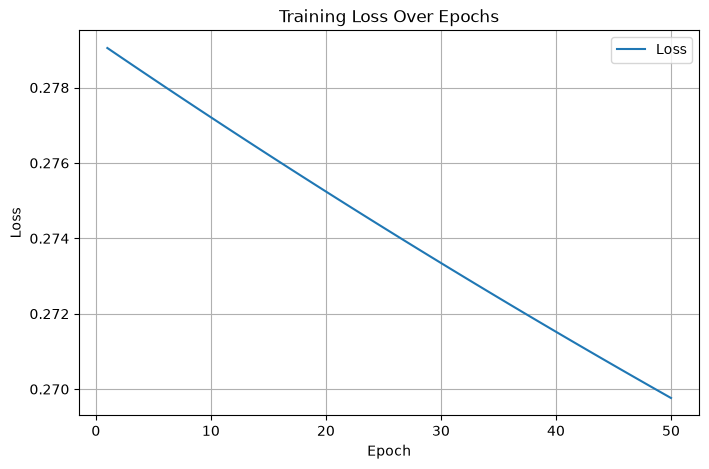

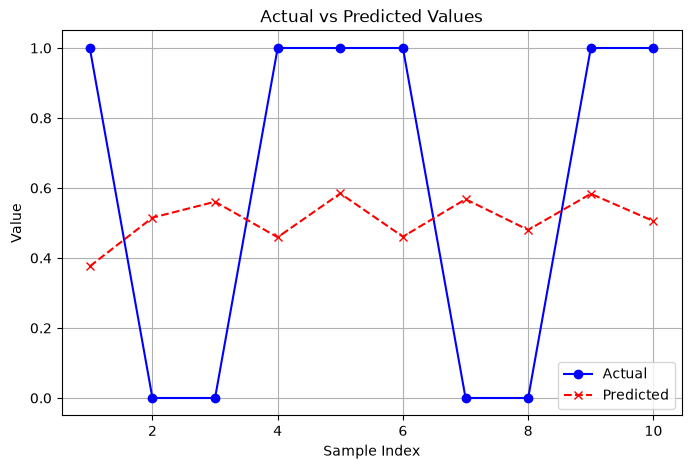

In [93]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 定义输入层大小、隐藏层大小、输出层大小和批量大小
n_in, n_h, n_out, batch_size = 10, 5, 1, 10

# 创建虚拟输入数据和目标数据
x = torch.randn(batch_size, n_in)  # 随机生成输入数据
y = torch.tensor([[1.0], [0.0], [0.0], 
                  [1.0], [1.0], [1.0], [0.0], [0.0], [1.0], [1.0]])  # 目标输出数据

# 创建顺序模型，包含线性层、ReLU激活函数和Sigmoid激活函数
model = nn.Sequential(
    nn.Linear(n_in, n_h),  # 输入层到隐藏层的线性变换
    nn.ReLU(),            # 隐藏层的ReLU激活函数
    nn.Linear(n_h, n_out),  # 隐藏层到输出层的线性变换
    nn.Sigmoid()           # 输出层的Sigmoid激活函数
)

# 定义均方误差损失函数和随机梯度下降优化器
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)  # 学习率为0.01

# 用于存储每轮的损失值
losses = []

# 执行梯度下降算法进行模型训练
for epoch in range(50):  # 迭代50次
    y_pred = model(x)  # 前向传播，计算预测值
    loss = criterion(y_pred, y)  # 计算损失
    losses.append(loss.item())  # 记录损失值
    print(f'Epoch [{epoch+1}/50], Loss: {loss.item():.4f}')  # 打印损失值

    optimizer.zero_grad()  # 清零梯度
    loss.backward()  # 反向传播，计算梯度
    optimizer.step()  # 更新模型参数

# 可视化损失变化曲线
plt.figure(figsize=(8, 5))
plt.plot(range(1, 51), losses, label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.grid()
plt.show()

# 可视化预测结果与实际目标值对比
y_pred_final = model(x).detach().numpy()  # 最终预测值
y_actual = y.numpy()  # 实际值

plt.figure(figsize=(8, 5))
plt.plot(range(1, batch_size + 1), y_actual, 'o-', label='Actual', color='blue')
plt.plot(range(1, batch_size + 1), y_pred_final, 'x--', label='Predicted', color='red')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid()
plt.show()

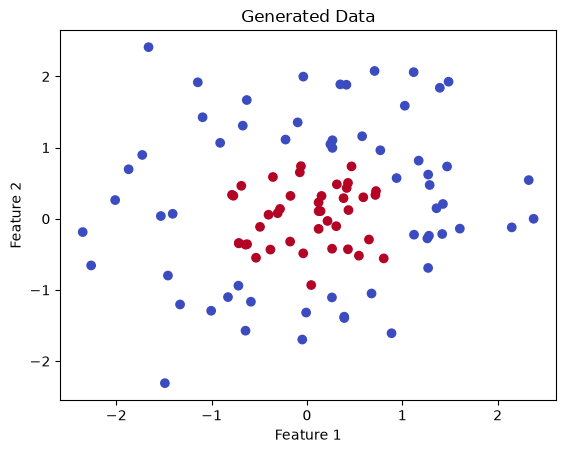

In [94]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 生成一些随机数据
n_samples = 100
data = torch.randn(n_samples, 2)  # 生成 100 个二维数据点
labels = (data[:, 0]**2 + data[:, 1]**2 < 1).float().unsqueeze(1)  # 点在圆内为1，圆外为0

# 可视化数据
plt.scatter(data[:, 0], data[:, 1], c=labels.squeeze(), cmap='coolwarm')
plt.title("Generated Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

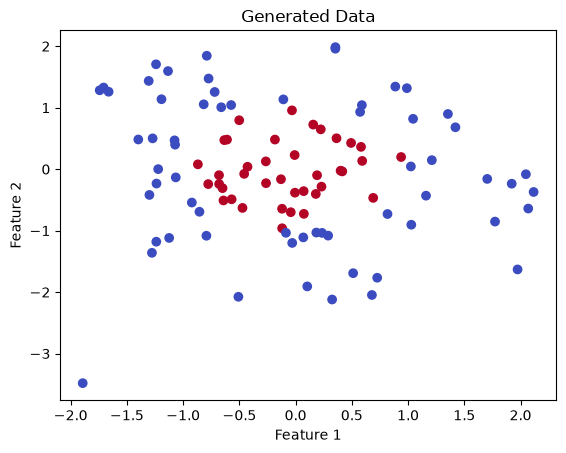

Epoch [10/100], Loss: 0.6562
Epoch [20/100], Loss: 0.6411
Epoch [30/100], Loss: 0.6332
Epoch [40/100], Loss: 0.6278
Epoch [50/100], Loss: 0.6232
Epoch [60/100], Loss: 0.6190
Epoch [70/100], Loss: 0.6148
Epoch [80/100], Loss: 0.6104
Epoch [90/100], Loss: 0.6053
Epoch [100/100], Loss: 0.6006


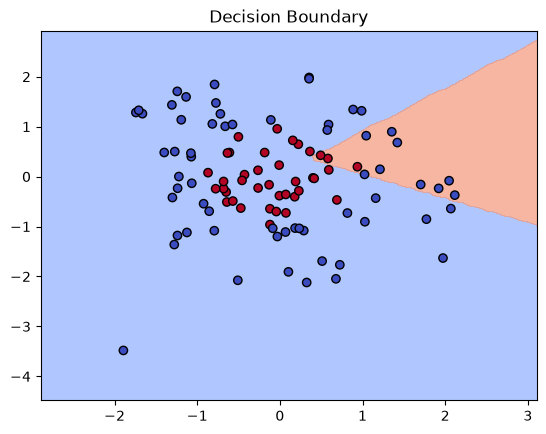

In [103]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 生成一些随机数据
n_samples = 100
data = torch.randn(n_samples, 2)  # 生成 100 个二维数据点
labels = (data[:, 0]**2 + data[:, 1]**2 < 1).float().unsqueeze(1)  # 点在圆内为1，圆外为0

# 可视化数据
plt.scatter(data[:, 0], data[:, 1], c=labels.squeeze(), cmap='coolwarm')
plt.title("Generated Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# 定义前馈神经网络
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        # 定义神经网络的层
        self.fc1 = nn.Linear(2, 4)  # 输入层有 2 个特征，隐藏层有 4 个神经元
        self.fc2 = nn.Linear(4, 1)  # 隐藏层输出到 1 个神经元（用于二分类）
        self.sigmoid = nn.Sigmoid()  # 二分类激活函数

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # 使用 ReLU 激活函数
        x = self.sigmoid(self.fc2(x))  # 输出层使用 Sigmoid 激活函数
        return x

# 实例化模型
model = SimpleNN()

# 定义损失函数和优化器
criterion = nn.BCELoss()  # 二元交叉熵损失
optimizer = optim.SGD(model.parameters(), lr=0.1)  # 使用随机梯度下降优化器

# 训练
epochs = 100
for epoch in range(epochs):
    # 前向传播
    outputs = model(data)
    loss = criterion(outputs, labels)

    # 反向传播
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 每 10 轮打印一次损失
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}')

# 可视化决策边界
def plot_decision_boundary(model, data):
    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
    xx, yy = torch.meshgrid(torch.arange(x_min, x_max, 0.1), torch.arange(y_min, y_max, 0.1), indexing='ij')
    grid = torch.cat([xx.reshape(-1, 1), yy.reshape(-1, 1)], dim=1)
    predictions = model(grid).detach().numpy().reshape(xx.shape)
    plt.contourf(xx, yy, predictions, levels=[0, 0.5, 1], cmap='coolwarm', alpha=0.7)
    plt.scatter(data[:, 0], data[:, 1], c=labels.squeeze(), cmap='coolwarm', edgecolors='k')
    plt.title("Decision Boundary")
    plt.show()

plot_decision_boundary(model, data)